In [1]:
# 1. IMPORTATIONS POUR LE M3 (Sélection + Random Forest)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing classique
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Outils pour la sélection de variables et l'optimisation
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error


In [2]:
# 2. CHARGEMENT DES DONNÉES ET PREPARATION DE LA TARGET

train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
# Toujours le log pour Kaggle !
y_train = np.log1p(train_df['SalePrice'])

X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [3]:
# 3. CRÉATION DU PREPROCESSOR (RobustScaler + OneHot)

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [4]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE ET TUNING (M3)

# Étape A : Le Filtre Lasso
# SelectFromModel va utiliser un LassoCV en interne. Il gardera uniquement les variables dont le coefficient n'a pas été réduit à 0.
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

# Étape B : Le Modèle Random Forest (Artillerie lourde)
# On initialise une Forêt Aléatoire de base
rf_model = RandomForestRegressor(random_state=42)

# Étape C : Assemblage de la Super Pipeline
pipeline_m3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('rf', rf_model)
])

# Étape D : Définition des hyperparamètres à tester pour le Random Forest
# On préfixe par 'rf__' car le modèle s'appelle 'rf' dans la pipeline
param_distributions = {
    'rf__n_estimators': [100, 300, 500],        # Nombre d'arbres dans la forêt
    'rf__max_depth': [10, 20, 30, None],        # Profondeur max (Complexité)
    'rf__min_samples_split': [2, 5, 10],        # Séparation minimale
    'rf__max_features': ['sqrt', 'log2', 1.0]   # Variables regardées par arbre
}

# Étape E : Lancement de l'optimisation (RandomizedSearchCV)
# Il va piocher 15 combinaisons au hasard (n_iter=15) et faire une Cross-Validation (cv=3)
random_search = RandomizedSearchCV(
    pipeline_m3,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error', # On cherche à minimiser le RMSE
    random_state=42,
    n_jobs=-1, # Utilise tous les processeurs de ton ordi
    verbose=1  # Affiche la progression
)

print("Lancement de la recherche d'hyperparamètres (cela peut prendre 1 à 2 minutes)...")
random_search.fit(X_train, y_train)

# Sauvegarde du meilleur modèle trouvé
best_m3_pipeline = random_search.best_estimator_

print("-" * 50)
print("Entraînement terminé ! Voici les meilleurs réglages trouvés pour la Forêt :")
print(random_search.best_params_)
print("-" * 50)

# Évaluation sur le Train Set
y_pred_train = best_m3_pipeline.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE (Log) sur le Train Set : {rmse_train:.4f}")

Lancement de la recherche d'hyperparamètres (cela peut prendre 1 à 2 minutes)...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
--------------------------------------------------
Entraînement terminé ! Voici les meilleurs réglages trouvés pour la Forêt :
{'rf__n_estimators': 500, 'rf__min_samples_split': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': None}
--------------------------------------------------
RMSE (Log) sur le Train Set : 0.0505


In [5]:
# 5. GÉNÉRATION DE LA SOUMISSION KAGGLE

# On prédit avec le meilleur modèle trouvé
preds_log_m3 = best_m3_pipeline.predict(X_test)
preds_dollars_m3 = np.expm1(preds_log_m3) # Retour au prix en dollars

submission_m3 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m3
})

fichier_soumission = 'M3_RandomForest_Submission.csv'
submission_m3.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.")

Fichier 'M3_RandomForest_Submission.csv' prêt ! Envoie-le sur Kaggle pour voir notre nouveau score.


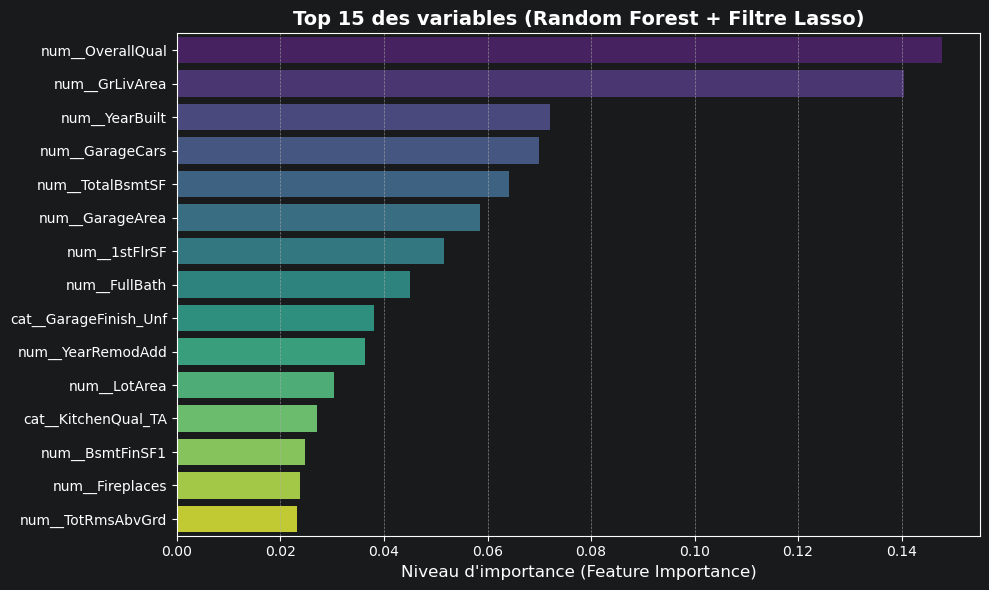

In [6]:
# 6. VISUALISATION : COMMENT LA FORÊT PREND SES DÉCISIONS ?

# Pour un Random Forest, l'importance des variables n'est pas "positive ou négative"
# comme un Lasso. C'est un pourcentage d'importance globale (de 0 à 1).

# 1. Récupérer toutes les variables créées par le preprocessor
toutes_variables = best_m3_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Récupérer le filtre (quelles variables le Lasso a laissé passer ?)
masque_lasso = best_m3_pipeline.named_steps['selector'].get_support()
variables_filtrees = toutes_variables[masque_lasso]

# 3. Récupérer l'importance donnée par le Random Forest
rf_importances = best_m3_pipeline.named_steps['rf'].feature_importances_

# 4. Créer le DataFrame et prendre le Top 15
rf_coef_df = pd.DataFrame({
    'Variable': variables_filtrees,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False).head(15)

# 5. Graphique avec Seaborn (version propre sans warning)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=rf_coef_df,
    x='Importance',
    y='Variable',
    hue='Variable',
    palette='viridis',
    legend=False
)

plt.title("Top 15 des variables (Random Forest + Filtre Lasso)", fontweight='bold', fontsize=14)
plt.xlabel("Niveau d'importance (Feature Importance)", fontsize=12)
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()